In [1]:
import numpy as np 
from mpl_toolkits import mplot3d
from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 14})
import pandas as pd
import random as rand
import matplotlib.animation as animation

In [3]:
#soil moisture loss function
def loss_func (ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss):
    if (ss <= sh):
        losses = 0
    elif ((ss > sh) and (ss <= sw)):
        losses = (ET_w/(n*Zr))*((ss-sh)/(sw-sh))
    elif ((ss > sw) and (ss <= s1)):
        losses = (ET_w + (ET_max - ET_w)*((ss-sw)/(s1-sw)))/(n*Zr)
    elif ((ss > s1) and (ss <= sfc)):
        losses = (ET_max/(n*Zr))
    else:
        losses = (ET_max/(n*Zr))+(1/(n*Zr))*(Ks/(np.exp(beta*(1-sfc))-1) * ((np.exp(beta*(ss-sfc))) - 1 ))
        
    return losses

# Soil Properties
def soil(x):
    if x == "loamy sand":
        n = 0.42 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [mm/day] at wilting point
        phis = -0.17*10**-3 #(MPa)
        b = 4.38
        sfc = 0.52 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.31 # soil moisture at onset of plant stress
        beta = 12.7 # soil term to calculate K(s) decay as part of leakage term
        Ks = 100 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.1362 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "sand":
        n = 0.35 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -0.34*10**-3 #(MPa)
        b = 4.05
        sfc = 0.35 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.33 # soil moisture at onset of plant stress
        beta = 12.1 # soil term to calculate K(s) decay as part of leakage term
        Ks = 200 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.154 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "loam":
        n = 0.45 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -1.43*10**-3 #(MPa)
        b = 5.39
        sfc = 0.65 # soil moisture at field capacity
        sw = 0.24 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.57 # soil moisture at onset of plant stress
        beta = 13.8 # soil term to calculate K(s) decay as part of leakage term
        Ks= 20 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)
        nn = 0.18 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    else:
        pass
    return n, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22

# Response of biotic H2 consuming bacteria to soil moisture 
def fh(ss):
    if ss <= swh:
        fs=0
    else:
        fs = (((ss-swh)**beta1)*((1-ss)**beta2))/(((sopt-swh)**beta1)*((1-sopt)**beta2))
    return fs

def fhm(ss, dm):
    if ss <= swh:
        fs = (0.01/swh)*ss
    #elif swh < ss <= dm:
        #fs = 1/100
    else:
        fs = (((ss-swh)**beta1)*((1-ss)**beta2))/(((sopt-swh)**beta1)*((1-sopt)**beta2))
    return fs

# Response of Organic Carbon consuming bacteria to soil moisture
def fc(ss):
    if ss <= sw:
        fs=0
    elif sw < ss <= sfc:
        fs = (ss - sw)/(sfc - sw)
    else:
        fs = sfc/ss
    return fs
#total conductance of the soil and diffusive barrier
def gt(ss):
    gt = ((n**2)*((1-ss)**(2+3/4.38))*(0.5**2)*0.756)/((n**2)*((1-ss)**(2+3/4.38)) +(0.5**2))
    return gt

# H2 Diffusive flux
def ff(ss,H):
    ff = gt(ss)*(Ha-H)
    return ff

# h2 biological sink
def bd(s, Cs, Bh):
    bd = hh*khh*fh(s)*Cs*Bh
    return bd

# Velocity that indicates the potential bological sink along depth Zr
def vbd(s, Cs, Bh):
    vbd = Zr*bd(s, Cs, Bh)
    return vbd
# Quasi steady approximation of H2 conecntration in the soil
def hyd(s, Cs, Bh):
    hyd = Ha/(1 + (vbd(s, Cs, Bh)/gt(s)))
    return hyd

# Considering Dormancy
def bdm(s, Cs, Bh, dm):
    bd = hh*khh*fhm(s, dm)*Cs*Bh
    return bd

def vbdm(s, Cs, Bh, dm):
    vbd = Zr*bdm(s, Cs, Bh, dm)
    return vbd

def hydm(s, Cs, Bh, dm):
    hyd = Ha/(1 + (vbdm(s, Cs, Bh, dm)/gt(s)))
    return hyd

def rainfall(y):
    alpha_p = 1.5 # average precipitation per event[cm]
    rainfall_ = np.zeros(int(length/dt))
    for i in range(0, int(length/dt)):
        r = np.random.default_rng().exponential(y)
        if r < y*dt:
            rainfall_[i] = np.random.default_rng().exponential(alpha_p/(n*Zr))
        else:
            rainfall_[i] = 0
    return rainfall_

In [4]:
n, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22 = soil("loamy sand") #soil parameters

In [5]:
length = 73000 # simulation time (days)
s0 = 0.5 # Soil moisture at the beginnig of the simulation [-]
Ha = 530  #(*Atmospheric concentration of hydrogen*)
dt = 0.001 # time interval (days)
time = np.linspace(0,length-dt,int(length/dt))

nut = np.zeros(int(length/dt))
rains_df = pd.DataFrame(nut, columns=["nut"])
freq = np.linspace(0.01, 0.71, 50) # Rainfall Frequency 

for i in range(len(freq)):
    y = round(freq[i],3)
    rain_vec = rainfall(y)
    rains_df[f"rain_{y}"] = rain_vec

In [8]:
# Soil moisture Equation solution
def run_ss(x):
    ss_vec = x.copy()
    for i in range(1, int(length/dt)):
        loss =  loss_func(ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss_vec[i-1])
        ss_vec[i] = ss_vec[i-1] + rain_vec[i] - dt*loss
        if ss_vec[i] >= 1:
            ss_vec[i] = 0.99
        else:
            pass
    return ss_vec

# Soil moisture drydown 
ss_dry = np.zeros(int(dry/dt))
ss_dry[0] = 1
def drydown(x):
    ss_vec = x.copy()
    for i in range(1, int(dry/dt)):
        loss =  loss_func(ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss_vec[i-1])
        ss_vec[i] = ss_vec[i-1] - dt*loss
            
    return ss_vec


In [9]:
ADD_max = 3.2 #g/m3/day
ADD_min = 0 #g/m3/day
khh = 3.2*10**-4 # Potential decomposition rate for hydrogen
kcc = 1.8*10**-3 # Potential decomposition rate for carbon
mc = 0.005 # Mortality rate for carbon microbes
mh = 0.005 # Mortality rate for Hydrogen microbes
rc = 0.6 # Respiration rate for Carbon microbes
rh = 0.6 # Respiration rate for Hydrogen microbes
q = 12*0.0072 # carbon to hydrogen ratio [C/H]

def ADD(s):
    ADD = ADD_max + (ADD_min - ADD_max)/(1 + (s/sfc)**3.31)
    return ADD

def substrate_sol(i, dm):
    # Dormancy condition
    if ss[i] <= dm:
        eta = 0
        mh = 0.00005 # Mortality rate for Hydrogen microbes
    else:
        eta = 1
        mh = 0.005 # Mortality rate for Hydrogen microbes
    kc = kcc*hh*fc(ss[i-1])
    kh = khh*hh*fhm(ss[i-1], dm)
    DEC_c = kc*Cs[i-1]*Bc[i-1]
    DEC_h = eta*q*kh*Cs[i-1]*Bh[i-1]*H[i-1]*n*(1-ss[i-1])
    BD_c = mc*Bc[i-1]
    BD_h = mh*Bh[i-1]
    cs = Cs[i-1] + dt*(ADd - DEC_c - DEC_h + BD_c + BD_h)
    return cs

def Microbe_c(i):
    kc = kcc*hh*fc(ss[i-1])
    DEC_c = kc*Cs[i-1]*Bc[i-1]
    BD_c = mc*Bc[i-1]
    bc = Bc[i-1] + dt*((1-rc)*DEC_c - BD_c)
    return bc

def Microbe_h(i, dm):
    # Dormancy condition
    if ss[i] <= dm:
        eta = 0
        mh = 0.00005 # Mortality rate for Hydrogen microbes
    else:
        eta = 1
        mh = 0.005 # Mortality rate for Hydrogen microbes
    kh = khh*hh*fhm(ss[i-1], dm)
    DEC_h = eta*q*kh*Cs[i-1]*Bh[i-1]*H[i-1]*n*(1-ss[i-1])
    BD_h = mh*Bh[i-1]
    bh = Bh[i-1] + dt*((1-rh)*DEC_h - BD_h)
    return bh

def run_hyd(i, dm):
    flux = ff(ss[i-1], H[i-1])
    b_d = bdm(ss[i-1], Cs[i-1], Bh[i-1], dm)*H[i-1]*Zr
    air = 1 - ss[i-1]
    H_vec = H[i-1] + ((flux - b_d))/(n*Zr*air) + H[i-1]*(ss[i] - ss[i-1])/air
    if H_vec > Ha:
        H_vec = Ha
    return H_vec


dm=0.0945
Cs = np.zeros(int(length/dt))
Cs[0] = 80
Bc = np.zeros(int(length/dt))
Bc[0] = 5
Bh = np.zeros(int(length/dt))
Bh[0] = 1
ss_vec = np.zeros(int(length/dt))
ss_vec[0] = s0

hyd_vec = np.zeros(int(length/dt)) #Quasi steady approximation
hyd_vec[0] = hydm(s0, Cs[0], Bh[0], dm)
H = np.zeros(int(length/dt))
H[0] = hyd_vec[0]

In [10]:
def fhn(ss):
    if ss <= sw:
        fs=0
    else:
        fs = (((ss-sw)**beta1)*((1-ss)**beta2))/nn
    return fs

def ADD(s):
    ADD = ADD_max + (ADD_min - ADD_max)/(1 + (s/sfc)**3.31)
    return ADD

def substrate_sol1(i):
    kc = kcc*hh*fc(ss[i-1])
    kh = khh*hh*fh(ss[i-1])
    DEC_c = kc*Cs1[i-1]*Bc1[i-1]
    DEC_h = q*kh*Cs1[i-1]*Bh1[i-1]*H1[i-1]*n*(1-ss[i-1])
    BD_c = mc*Bc1[i-1]
    BD_h = mh*Bh1[i-1]
    cs = Cs1[i-1] + dt*(ADd - DEC_c - DEC_h + BD_c + BD_h)
    return cs

def Microbe_c1(i):
    kc = kcc*hh*fc(ss[i-1])
    DEC_c = kc*Cs1[i-1]*Bc1[i-1]
    BD_c = mc*Bc1[i-1]
    bc = Bc1[i-1] + dt*((1-rc)*DEC_c - BD_c)
    return bc

def Microbe_h1(i):
    kh = khh*hh*fh(ss[i-1])
    DEC_h = q*kh*Cs1[i-1]*Bh1[i-1]*H1[i-1]*n*(1-ss[i-1])
    BD_h = mh*Bh1[i-1]
    bh = Bh1[i-1] + dt*((1-rh)*DEC_h - BD_h)
    return bh

def run_hyd1(i):
    flux = ff(ss[i-1], H1[i-1])
    b_d = hh*khh*fh(ss[i-1])*Cs1[i-1]*Bh1[i-1]*H1[i-1]*Zr
    air = 1 - ss[i-1]
    H_vec = H1[i-1] + (flux - b_d)/(n*Zr*air) + H1[i-1]*(ss[i] - ss[i-1])/air
    if H_vec > 530:
        H_vec = 530
    return H_vec
def hyd1(s, Cs, Bh):
    hyd = Ha/(1 + (hh*khh*fh(s)*Cs*Bh*Zr)/gt(s))
    return hyd

def vbdn(s, Cs, Bh):
    vbd = Zr*hh*khh*fh(s)*Cs*Bh
    return vbd

Cs1 = np.zeros(int(length/dt))
Cs1[0] = 80
Bc1 = np.zeros(int(length/dt))
Bc1[0] = 5
Bh1 = np.zeros(int(length/dt))
Bh1[0] = 1

hyd_vec1 = np.zeros(int(length/dt)) #Quasi steady approximation
hyd_vec1[0] = hyd1(s0, Cs1[0], Bh1[0])
H1 = np.zeros(int(length/dt))
H1[0] = hyd_vec1[0]

In [11]:
H_df = pd.DataFrame(nut, columns=["nut"])
H_mean = []
H_sd = []
cs_df = pd.DataFrame(nut, columns=["nut"])
cs_mean = []
cs_sd = []
bc_df = pd.DataFrame(nut, columns=["nut"])
bc_mean = []
bc_sd = []
bh_df = pd.DataFrame(nut, columns=["nut"])
bh_mean = []
bh_sd = []
vd_df = pd.DataFrame(nut, columns=["nut"])
vd_mean = []
vd_sd = []
ss_df = pd.DataFrame(nut, columns=["nut"])
ss_mean = []
ss_sd = []
hyd_df = pd.DataFrame(nut, columns=["nut"])
hyd_mean = []
hyd_sd = []
VV = np.zeros(int(length/dt))

H1_df = pd.DataFrame(nut, columns=["nut"])
H1_mean = []
H1_sd = []
cs1_df = pd.DataFrame(nut, columns=["nut"])
cs1_mean = []
cs1_sd = []
bc1_df = pd.DataFrame(nut, columns=["nut"])
bc1_mean = []
bc1_sd = []
bh1_df = pd.DataFrame(nut, columns=["nut"])
bh1_mean = []
bh1_sd = []
vd1_df = pd.DataFrame(nut, columns=["nut"])
vd1_mean = []
vd1_sd = []
hyd1_df = pd.DataFrame(nut, columns=["nut"])
hyd1_mean = []
hyd1_sd = []
VV1 = np.zeros(int(length/dt))

In [12]:
for i in range(0, 9):
    y = round(freq[i], 2)
    rain_vec = rains_df[f"rain_{y}"]
    ss = run_ss(ss_vec)
    ss_df[f"ss_{y}"] = ss
    ADd = ADD(np.mean(ss))
    #ss_mean.append(np.mean(ss)2
    #ss_sd.append(np.std(ss))
    for i in range(1, int(length/dt)):
        # Dormancy
        Bc[i] = Microbe_c(i)
        Cs[i] = substrate_sol(i, dm)
        Bh[i] = Microbe_h(i, dm)
        H[i] = run_hyd(i, dm)
        hyd_vec[i] = hydm(ss[i], Cs[i], Bh[i], dm)
        # No Dormancy
        Bc1[i] = Microbe_c1(i)
        Cs1[i] = substrate_sol1(i)
        Bh1[i] = Microbe_h1(i)
        H1[i] = run_hyd1(i)
        hyd_vec1[i] = hyd1(ss[i], Cs1[i], Bh1[i])
    for k in range(int(length/dt)):
        VV[k] = gt(ss[k])*vbdm(ss[k], Cs[k], Bh[k], dm)/(gt(ss[k])+vbdm(ss[k], Cs[k], Bh[k], dm))
        VV1[k] = gt(ss[k])*vbdn(ss[k], Cs1[k], Bh1[k])/(gt(ss[k])+vbdn(ss[k], Cs1[k], Bh1[k]))
    H_df[f"H_{y}"] = H
    cs_df[f"cs_{y}"] = Cs
    bh_df[f"bh_{y}"] = Bh
    bc_df[f"bc_{y}"] = Bc
    hyd_df[f"hyd_{y}"] = hyd_vec
    vd_df[f"v_{y}"] = VV
    # No Dormancy
    H1_df[f"H_{y}"] = H1
    cs1_df[f"cs_{y}"] = Cs1
    bh1_df[f"bh_{y}"] = Bh1
    bc1_df[f"bc_{y}"] = Bc1
    hyd1_df[f"hyd_{y}"] = hyd_vec1
    vd1_df[f"v_{y}"] = VV1
    

In [19]:
for i in range(9, 17):
    y = round(freq[i], 2)
    rain_vec = rains_df[f"rain_{y}"]
    ss = run_ss(ss_vec)
    ss_df[f"ss_{y}"] = ss
    ADd = ADD(np.mean(ss))
    #ss_mean.append(np.mean(ss)2
    #ss_sd.append(np.std(ss))
    for i in range(1, int(length/dt)):
        # Dormancy
        Bc[i] = Microbe_c(i)
        Cs[i] = substrate_sol(i, dm)
        Bh[i] = Microbe_h(i, dm)
        H[i] = run_hyd(i, dm)
        hyd_vec[i] = hydm(ss[i], Cs[i], Bh[i], dm)
        # No Dormancy
        Bc1[i] = Microbe_c1(i)
        Cs1[i] = substrate_sol1(i)
        Bh1[i] = Microbe_h1(i)
        H1[i] = run_hyd1(i)
        hyd_vec1[i] = hyd1(ss[i], Cs1[i], Bh1[i])
    for k in range(int(length/dt)):
        VV[k] = gt(ss[k])*vbdm(ss[k], Cs[k], Bh[k], dm)/(gt(ss[k])+vbdm(ss[k], Cs[k], Bh[k], dm))
        VV1[k] = gt(ss[k])*vbdn(ss[k], Cs1[k], Bh1[k])/(gt(ss[k])+vbdn(ss[k], Cs1[k], Bh1[k]))
    H_df[f"H_{y}"] = H
    cs_df[f"cs_{y}"] = Cs
    bh_df[f"bh_{y}"] = Bh
    bc_df[f"bc_{y}"] = Bc
    hyd_df[f"hyd_{y}"] = hyd_vec
    vd_df[f"v_{y}"] = VV
    # No Dormancy
    H1_df[f"H_{y}"] = H1
    cs1_df[f"cs_{y}"] = Cs1
    bh1_df[f"bh_{y}"] = Bh1
    bc1_df[f"bc_{y}"] = Bc1
    hyd1_df[f"hyd_{y}"] = hyd_vec1
    vd1_df[f"v_{y}"] = VV1
    

In [20]:
# Append mean for dormancy
H_mean = H_df.mean()
bh_mean = bh_df.mean()
bc_mean = bc_df.mean()
cs_mean = cs_df.mean()
hyd_mean = hyd_df.mean()
vd_mean = vd_df.mean()
H_sd = H_df.std()
bh_sd = bh_df.std()
bc_sd = bc_df.std()
cs_sd = cs_df.std()
hyd_sd = hyd_df.std()
vd_sd = vd_df.std()

In [21]:
# Append mean for dormancy
H1_mean = H1_df.mean()
bh1_mean = bh1_df.mean()
bc1_mean = bc1_df.mean()
cs1_mean = cs1_df.mean()
hyd1_mean = hyd1_df.mean()
vd1_mean = vd1_df.mean()
H1_sd = H1_df.std()
bh1_sd = bh1_df.std()
bc1_sd = bc1_df.std()
cs1_sd = cs1_df.std()
hyd1_sd = hyd1_df.std()
vd1_sd = vd1_df.std()

In [22]:
ss_mean = ss_df.mean()
ss_sd = ss_df.std()

In [25]:
H_df.to_csv("H_pdf.csv")
cs_df.to_csv("Cs_pdf.csv")
bc_df.to_csv("Bc_pdf.csv")
bh_df.to_csv("Bh_pdf.csv")
hyd_df.to_csv("Hyd_pdf.csv")
vd_df.to_csv("Vd_pdf.csv")
ss_df.to_csv("SS_pdf.csv")

In [26]:
H1_df.to_csv("H1_pdf.csv")
cs1_df.to_csv("Cs1_pdf.csv")
bc1_df.to_csv("Bc1_pdf.csv")
bh1_df.to_csv("Bh1_pdf.csv")
hyd1_df.to_csv("Hyd1_pdf.csv")
vd1_df.to_csv("Vd1_pdf.csv")

In [35]:
vd1_df.to_csv("Vd1.csv")

In [2]:
df = pd.read_excel("Meanss.xlsx", sheet_name="Sheet2") 
df

,R frequency,ET_max,mean rainfall,DI,ss,cs,bh,bc,H,hyd,vd,cs1,bh1,bc1,H1,hyd1,vd1,Ratio,Ratio1
0,0.010,0.45,1.5,30.000000,0.062272,76.171142,2.511432,0.078167,201.213732,201.340802,0.042488,22.581099,0.926198,0.078038,377.199919,377.276915,0.019541,96.981500,92.229091
1,0.014,0.45,1.5,21.428571,0.072191,76.612967,2.653356,0.077927,136.855089,136.954014,0.050328,18.644083,1.173407,0.077793,333.498846,333.546984,0.024900,97.146868,93.782502
2,0.018,0.45,1.5,16.666667,0.078695,82.097622,2.655226,0.079385,103.327492,103.415678,0.054189,20.755104,1.381593,0.079331,295.488799,295.544713,0.029586,97.097044,94.569801
3,0.022,0.45,1.5,13.636364,0.087447,80.067992,2.720531,0.085617,64.418134,64.482322,0.058535,19.930743,1.711895,0.085108,234.854842,234.894667,0.036882,96.948949,95.263870
4,0.026,0.45,1.5,11.538462,0.090094,80.643528,2.725828,0.086010,55.130328,55.164635,0.059481,21.696294,1.817989,0.085855,215.522684,215.553054,0.039249,96.941150,95.490460
5,0.030,0.45,1.5,10.000000,0.094294,91.826681,2.711591,0.081961,37.395969,37.439833,0.061404,23.659880,2.031202,0.081437,176.368303,176.417780,0.043926,97.066070,96.145262
6,0.034,0.45,1.5,8.823529,0.097563,93.465551,2.724782,0.091204,32.790404,32.815317,0.061622,24.347496,2.189297,0.090839,144.892875,144.916982,0.047573,96.761193,96.016074
7,0.038,0.45,1.5,7.894737,0.101612,93.149875,2.748312,0.103353,23.475461,23.487045,0.062414,28.570892,2.404978,0.102925,103.916751,103.931074,0.052417,96.375704,95.895976
8,0.042,0.45,1.5,7.142857,0.105591,104.128749,2.740321,0.087873,17.431929,17.436461,0.062723,38.275301,2.639963,0.087473,57.700281,57.707046,0.057756,96.892952,96.792855
9,0.046,0.45,1.5,6.521739,0.107093,102.425352,2.732989,0.106238,18.758527,18.764930,0.062361,43.130602,2.684946,0.105002,46.647561,46.657646,0.058910,96.258213,96.236401


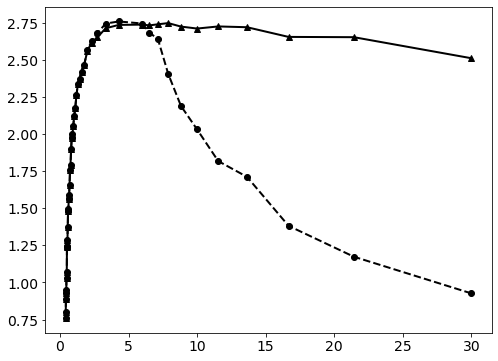

In [12]:
plt.figure(figsize=(8,6))
plt.plot(df.DI, df.bh, color="k", linewidth=2, marker='^')
plt.plot(df.DI, df.bh1, color="k", linewidth=2, linestyle="dashed", marker='o')

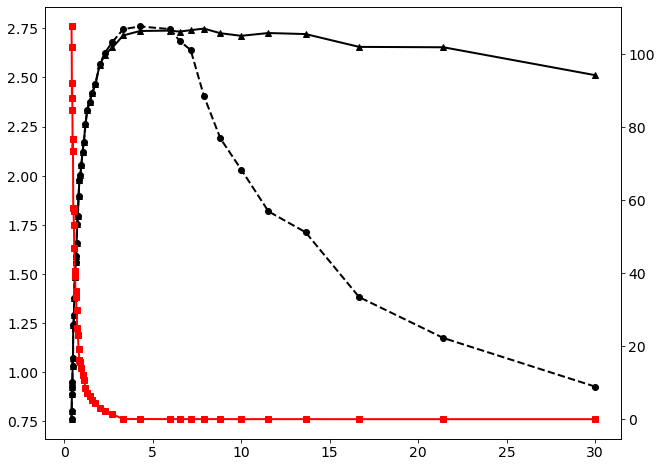

In [10]:
fig = plt.figure()
fig.set_figwidth(8)
fig.set_figheight(6)
ax1 = fig.add_axes([0,0,1,1])
ax1.plot(df.DI, df.bh, color="k", linewidth=2, marker='^')
ax1.plot(df.DI, df.bh1, color="k", linewidth=2, linestyle="dashed", marker='o')
ax2=ax1.twinx()
ax2.plot(df.DI, df.bc, color="red", linewidth=2, marker='s');
#ax2.set_ylim([-1,60]);

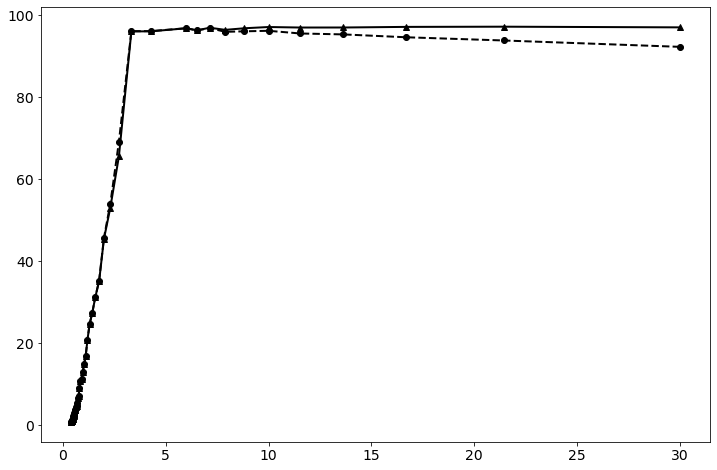

In [10]:
plt.figure(figsize=(12,8))
plt.plot(df.DI, df.Ratio, color="k", linewidth=2, marker='^')
plt.plot(df.DI, df.Ratio1, color="k", linewidth=2, linestyle="dashed", marker='o')

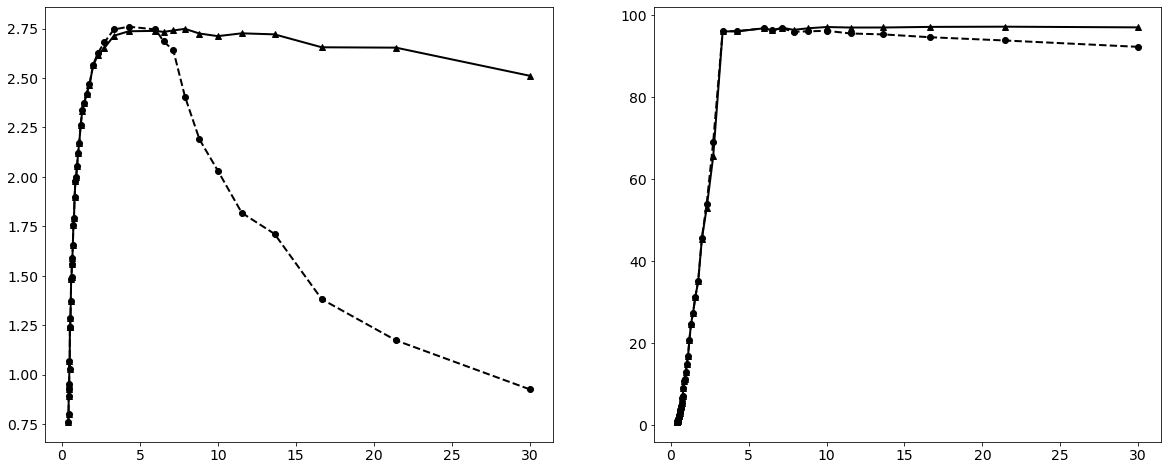

In [13]:
# Figure 8
fig, axs = plt.subplots(1, 2, figsize=(20,8))
plt.subplots_adjust(wspace=0.2)
axs[0].plot(df.DI, df.bh, color="k", linewidth=2, marker='^')
axs[0].plot(df.DI, df.bh1, color="k", linewidth=2, linestyle="dashed", marker='o')
axs[1].plot(df.DI, df.Ratio, color="k", linewidth=2, marker='^')
axs[1].plot(df.DI, df.Ratio1, color="k", linewidth=2, linestyle="dashed", marker='o')

In [5]:
Means = pd.read_csv("Means.csv")
sds = pd.read_csv("sds.csv")